In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from itertools import combinations
import cmocean as cmc
import cmcrameri as cmcr
from scipy.stats import spearmanr

#plt.style.use('../plotstyling.mplstyle')

In [2]:
db_filename = "../../../DataStorage/AWS/for_cloud_filtering/combined_2025-11-10_2025-12-22_2026-01-20_and_2026-02-05_arcitc_antarctica_training.nc"
ds = xr.open_dataset(db_filename)

In [3]:
NEDeltaT = np.array([0.21, 0.36, 0.50, 0.56, 0.79, 0.84, 1.0, 0.91, 1.05, 1.53, 1.6])

Fwp = ds.Fwp.values
Fwc = ds.Fwc.values
Zm = ds.Fwp_Zm.values / 1000
Latitude = ds.Latitude.values
Longitude = ds.Longitude.values
Surf_z = ds.Surf_Z.values
altitude = ds.vertical_level.values / 1000
altitude_in_m = ds.vertical_level.values
TCWV = ds.H2O_Column.values

channels = ["AWS21", "AWS31", "AWS32", "AWS33", "AWS34", "AWS35", "AWS36", "AWS44", "AWS43", "AWS42", "AWS41"]
channels_diffs = ["21-31", "31-32", "32-33", "33-34", "34-35", "35-36", "36-44", "44-43", "43-42", "42-41"]

Ta_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    Ta_array[:,i] = ds[f"Ta_Allsky_{ch}"].values

CS_array = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array[:,i] = ds[f"Ta_Clearsky_{ch}"].values - ds[f"Ta_Allsky_{ch}"].values

CS_array_noisy = np.zeros((Latitude.shape[0], len(channels)))
for i, ch in enumerate(channels):
    CS_array_noisy[:,i] = CS_array[:,i] + np.random.normal(0, NEDeltaT[i], CS_array[:,i].shape[0])


In [4]:
ds.H2O_Column.values.mean()

np.float64(19.74976785065037)

In [5]:
Fwp_bins = np.array([1e-2, 5e-2, 1e-1, 5e-1, 1e0])

#Fwp_bins = np.linspace(1e-3, 1, 10)


#Fwp_bins = np.array([5e-3, 2e-1, 1])
layer_height = 8
layer_edges = list(range(0, len(altitude_in_m) - 1, layer_height))[1:-3]

channel_idxs = [3, 7] # channels 12 (33) and 19 (44)

y_labels = [
    f"{(altitude_in_m[start] + altitude_in_m[start + layer_height - 1]) / 2 / 1000:.1f} km"
    for start in layer_edges
]

#fwp_labels = [f"$10^{{{int(np.log10(b))}}}$" if np.log10(b) % 1 == 0 
#              else f"$5\\times10^{{{int(np.floor(np.log10(b)))}}}$" 
#              for b in Fwp_bins]

fwp_labels = [f"{b:.3g}" for b in Fwp_bins]

In [10]:
np.linspace(1e-3, 1, 10)

array([0.001, 0.112, 0.223, 0.334, 0.445, 0.556, 0.667, 0.778, 0.889,
       1.   ])

In [11]:
y_labels

['2.9 km', '4.9 km', '6.9 km', '8.9 km', '10.9 km', '12.9 km']

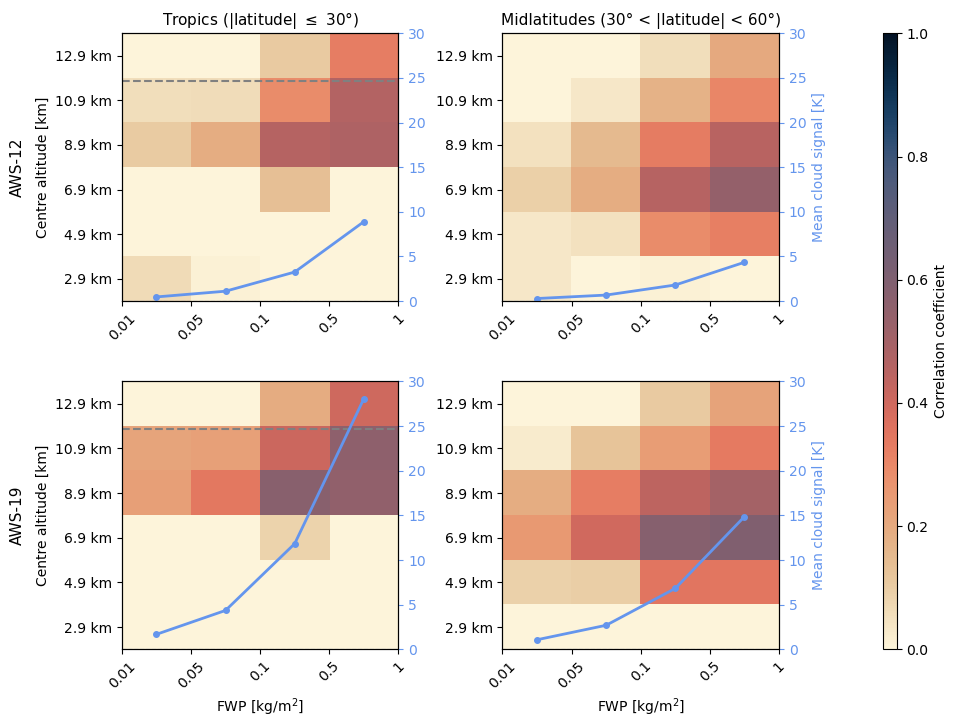

In [9]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.05], figure=fig, hspace=0.3, wspace=0.55)
axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)])
cax = fig.add_subplot(gs[:, 2])

# --- tropical ---
correlations = {ch_idx: np.zeros((len(layer_edges), len(Fwp_bins)-1)) for ch_idx in channel_idxs}
mean_CS = {ch_idx: {"trop": np.zeros(len(Fwp_bins)-1), 
                    "mid":  np.zeros(len(Fwp_bins)-1)} for ch_idx in channel_idxs}

for k in range(len(Fwp_bins)-1):
    fwp_idxs = np.where(
        (Fwp >= Fwp_bins[k]) & (Fwp < Fwp_bins[k+1]) & (np.abs(Latitude) <= 30)
    )[0]
    for i, start in enumerate(layer_edges):
        Fwc_layer = Fwc[fwp_idxs, start:start + layer_height]
        z = altitude_in_m[start:start + layer_height]
        Fwp_layer = np.trapezoid(Fwc_layer, z)
        valid = Fwp_layer > 0
        for ch_idx in channel_idxs:
            #r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[fwp_idxs][valid, ch_idx])[0, 1]
            r, _ = spearmanr(Fwp_layer[valid], CS_array_noisy[fwp_idxs][valid, ch_idx])
            correlations[ch_idx][i, k] = r
            
    for ch_idx in channel_idxs:
        mean_CS[ch_idx]["trop"][k] = np.mean(CS_array_noisy[fwp_idxs, ch_idx])

axes[0, 0].imshow(correlations[3][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)
axes[1, 0].imshow(correlations[7][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)

# --- midlatitude ---
correlations = {ch_idx: np.zeros((len(layer_edges), len(Fwp_bins)-1)) for ch_idx in channel_idxs}
for k in range(len(Fwp_bins)-1):
    fwp_idxs = np.where(
        (Fwp >= Fwp_bins[k]) & (Fwp < Fwp_bins[k+1]) & (np.abs(Latitude) > 30) & (np.abs(Latitude) < 60)
    )[0]
    for i, start in enumerate(layer_edges):
        Fwc_layer = Fwc[fwp_idxs, start:start + layer_height]
        z = altitude_in_m[start:start + layer_height]
        Fwp_layer = np.trapezoid(Fwc_layer, z)
        valid = Fwp_layer > 0
        for ch_idx in channel_idxs:
            #r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[fwp_idxs][valid, ch_idx])[0, 1]
            r, _ = spearmanr(Fwp_layer[valid], CS_array_noisy[fwp_idxs][valid, ch_idx])
            correlations[ch_idx][i, k] = r
    
    for ch_idx in channel_idxs:
        mean_CS[ch_idx]["mid"][k] = np.mean(CS_array_noisy[fwp_idxs, ch_idx])

im = axes[0, 1].imshow(correlations[3][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)
axes[1, 1].imshow(correlations[7][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)

bin_centres = np.arange(len(Fwp_bins) - 1)

for row, ch_idx in enumerate(channel_idxs):
    for col, region in enumerate(["trop", "mid"]):
        ax_twin = axes[row, col].twinx()
        ax_twin.plot(bin_centres, mean_CS[ch_idx][region], 
                     color="cornflowerblue", lw=2, marker="o", ms=4, label="Mean CS")
        ax_twin.axhline(0, color="cornflowerblue", lw=0.8, ls="--")
        ax_twin.set_ylabel("Mean cloud signal [K]" if col == 1 else "")
        #if col == 0:
        #    ax_twin.set_yticks([])
        ax_twin.set_ylim([0,30])
        ax_twin.tick_params(axis='y', colors='cornflowerblue')
        ax_twin.yaxis.label.set_color('cornflowerblue')
        ax_twin.axhline(NEDeltaT[ch_idx], ls="--", c="grey")
        #axes[1,0].axhline(NEDeltaT[channel_idxs[0]], ls="--", c="grey")

            
# --- formatting ---
#col_titles = ["Tropics (|lat| < 30°), TCWV > 40 kg/m$^{2}$", "Midlatitudes (30° < |lat| < 60°), TCWV > 40 kg/m$^{2}$"]
col_titles = ["Tropics (|latitude| $\leq$ 30°)", "Midlatitudes (30° < |latitude| < 60°)"]
row_titles = ["AWS-12", "AWS-19"]

for col in range(2):
    axes[0, col].set_title(col_titles[col], fontsize=11)
for row in range(2):
    axes[row, 0].set_ylabel("Centre altitude [km]")
    axes[row, 0].set_yticks(range(len(y_labels)))
    axes[row, 1].set_yticks(range(len(y_labels)))
    axes[row, 0].set_yticklabels(y_labels[::-1])
    axes[row, 1].set_yticklabels(y_labels[::-1])
    axes[row, 0].text(-0.35, 0.5, row_titles[row], transform=axes[row, 0].transAxes,
                      fontsize=11, va="center", ha="right", rotation=90)
    for col in range(2):
        axes[row, col].set_xticks(np.arange(len(Fwp_bins)) - 0.5)
        axes[row, col].set_xticklabels(fwp_labels, rotation=45)
        axes[1, col].set_xlabel("FWP [kg/m$^{2}]$")
        #if col == 1:
        #    axes[row, col].set_yticks([])
        #if row == 0:
        #    axes[row, col].set_xticks([])

fig.colorbar(im, cax=cax, label="Correlation coefficient")
plt.savefig("../figures/correlations/FWP_vs_altitude_heatmaps_lower_range_spearman.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("../figures/correlations/FWP_vs_altitude_heatmaps.pdf",
            dpi=200, bbox_inches="tight", facecolor="white")

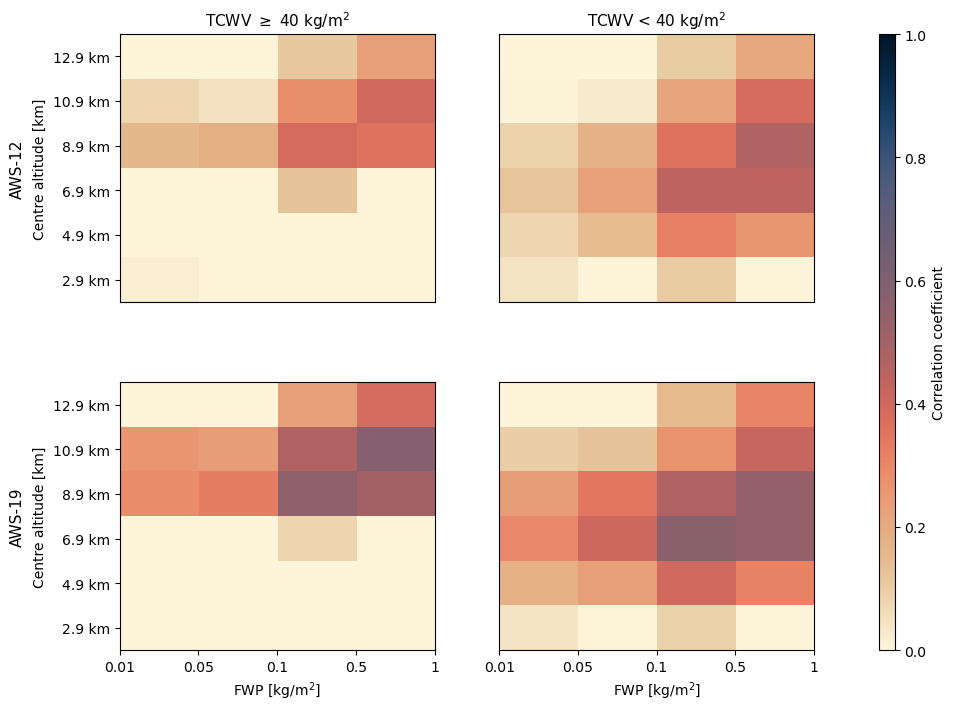

In [13]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.05], figure=fig, hspace=0.3, wspace=0.3)
axes = np.array([[fig.add_subplot(gs[row, col]) for col in range(2)] for row in range(2)])
cax = fig.add_subplot(gs[:, 2])

# --- high tcwv ---
correlations = {ch_idx: np.zeros((len(layer_edges), len(Fwp_bins)-1)) for ch_idx in channel_idxs}
for k in range(len(Fwp_bins)-1):
    # --- high TCWV ---
    fwp_idxs = np.where(
        (Fwp >= Fwp_bins[k]) & (Fwp < Fwp_bins[k+1]) & (TCWV >= 40)
    )[0]
    for i, start in enumerate(layer_edges):
        Fwc_layer = Fwc[fwp_idxs, start:start + layer_height]
        z = altitude_in_m[start:start + layer_height]
        Fwp_layer = np.trapezoid(Fwc_layer, z)
        valid = Fwp_layer > 0
        for ch_idx in channel_idxs:
            r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[fwp_idxs][valid, ch_idx])[0, 1]
            correlations[ch_idx][i, k] = r

axes[0, 0].imshow(correlations[3][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)
axes[1, 0].imshow(correlations[7][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)

# --- low tcwv ---
correlations = {ch_idx: np.zeros((len(layer_edges), len(Fwp_bins)-1)) for ch_idx in channel_idxs}
for k in range(len(Fwp_bins)-1):
    fwp_idxs = np.where(
        (Fwp >= Fwp_bins[k]) & (Fwp < Fwp_bins[k+1]) & (TCWV < 40)
    )[0]
    for i, start in enumerate(layer_edges):
        Fwc_layer = Fwc[fwp_idxs, start:start + layer_height]
        z = altitude_in_m[start:start + layer_height]
        Fwp_layer = np.trapezoid(Fwc_layer, z)
        valid = Fwp_layer > 0
        for ch_idx in channel_idxs:
            r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[fwp_idxs][valid, ch_idx])[0, 1]
            correlations[ch_idx][i, k] = r

im = axes[0, 1].imshow(correlations[3][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)
axes[1, 1].imshow(correlations[7][::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)

# --- formatting ---
#col_titles = ["Tropics (|lat| < 30°), TCWV > 40 kg/m$^{2}$", "Midlatitudes (30° < |lat| < 60°), TCWV > 40 kg/m$^{2}$"]
col_titles = ["TCWV $\geq$ 40 kg/m$^{2}$", "TCWV < 40 kg/m$^{2}$"]
row_titles = ["AWS-12", "AWS-19"]

for col in range(2):
    axes[0, col].set_title(col_titles[col], fontsize=11)
for row in range(2):
    axes[row, 0].set_ylabel("Centre altitude [km]")
    axes[row, 0].set_yticks(range(len(y_labels)))
    axes[row, 0].set_yticklabels(y_labels[::-1])
    axes[row, 0].text(-0.3, 0.5, row_titles[row], transform=axes[row, 0].transAxes,
                      fontsize=11, va="center", ha="right", rotation=90)
    for col in range(2):
        axes[row, col].set_xticks(np.arange(len(Fwp_bins)) - 0.5)
        axes[row, col].set_xticklabels(fwp_labels)
        axes[1, col].set_xlabel("FWP [kg/m$^{2}]$")
        if col == 1:
            axes[row, col].set_yticks([])
        if row == 0:
            axes[row, col].set_xticks([])

fig.colorbar(im, cax=cax, label="Correlation coefficient")
plt.savefig("../figures/correlations/FWP_vs_altitude_heatmaps_by_TCWV.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [11]:
layer_height = 8
iters = range(2, len(altitude_in_m) + 1, layer_height)
n_iters = len(range(2, len(altitude_in_m) + 1, layer_height))
correlations = np.zeros((n_iters-1, 11))

for i, n in enumerate(iters):
    if i == 0:
        continue
    Fwc_layer = Fwc[filter_idxs, -n:]
    z = altitude_in_m[-n:]
    Fwp_layer = np.trapezoid(Fwc_layer, z)

    valid = Fwp_layer > 0

    #log_Fwp = np.log10(Fwp_layer[valid])
    for j in range(11):
        #r = np.corrcoef(log_Fwp, CS_array_noisy[filter_idxs][valid, j])[0, 1]
        r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])[0, 1]
        correlations[i-1, j] = r
    
    #for j in range(11):
    #    r, _ = spearmanr(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])
    #    correlations[i, j] = r

y_labels = [
    f"{altitude_in_m[-n]/1000:.2f}–{altitude_in_m[-1]/1000:.1f}"
    for n in range(2, len(altitude_in_m) + 1, layer_height)
]

    plt.savefig(
        f"../figures/deep_convection/map_{case}_{zm_limit}.png",
        dpi=200,
        bbox_inches="tight",
        facecolor="white")


IndentationError: unexpected indent (544390724.py, line 30)

In [ ]:

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.imshow(correlations, aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)

plt.colorbar(im, ax=ax, label="r")

ax.set_xticks(range(11))
ax.set_xticklabels([f"{ch}" for ch in channels])
ax.set_yticks(range(len(y_labels)-1))
ax.set_yticklabels(y_labels[1:])

ax.set_ylabel("Partial column [km]")
#ax.set_title(f"Correlation between Fwp and cloud signal\n{title}\nPartial columns")
#ax.set_title(f"Correlation between Fwp and cloud signal\nALL")

plt.tight_layout()
plt.savefig(
    f"../figures/correlations/CS_FWP_correlation_{case}_partial_columns_no_log_no_zeros.png",
    dpi=200,
    bbox_inches="tight",
    facecolor="white")

In [ ]:
# ── compute correlations ──
layer_height = 8
layer_edges = list(range(0, len(altitude_in_m) - 1, layer_height))[1:-2]

correlations_no_overlap = np.zeros((len(layer_edges), 11))
for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)
    valid = Fwp_layer > 0
    for j in range(11):
        r = np.corrcoef(Fwp_layer[valid], CS_array_noisy[filter_idxs][valid, j])[0, 1]
        correlations_no_overlap[i, j] = r

# ── correlation with total FWP ──
valid_total = Fwp[filter_idxs] > 0
corr_total = np.array([
    np.corrcoef(Fwp[filter_idxs][valid_total], CS_array_noisy[filter_idxs][valid_total, j])[0, 1]
    for j in range(11)
])
correlations_with_total = np.vstack([correlations_no_overlap, corr_total])

y_labels = [
    f"{(altitude_in_m[start] + altitude_in_m[start + layer_height - 1]) / 2 / 1000:.1f} km"
    for start in layer_edges
]
y_labels_with_total = y_labels + ["Total FWP"]

# ── plot ──
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(correlations_with_total[::-1], aspect="auto", cmap=cmcr.cm.lipari_r, vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Correlation coefficient")
ax.set_xticks(range(11))
ax.set_xticklabels([f"AWS-{i+9}" for i, ch in enumerate(channels[:-4])] + ["AWS-19", "AWS-18", "AWS-17", "AWS-16"], rotation=45, ha="right")
ax.set_yticks(range(len(y_labels_with_total)))
ax.set_yticklabels(y_labels_with_total[::-1])
ax.set_ylabel("Centre altitude of vertical layer [km]")
ax.set_xlabel("Cloud signal [K]")
#ax.set_title(f"Correlation between layer FWP and CS\n{title}\nSpecific layers")
ax.axhline(y=0.5, color="white", linewidth=2)
plt.tight_layout()
plt.savefig(f"../figures/correlations/CS_FWP_correlation_5_200.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig(f"../figures/correlations/CS_FWP_correlation_5_200.pdf",
            dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
for start in layer_edges:
    print(f"{altitude_in_m[start]/1e3:.2f} – {altitude_in_m[start + layer_height - 1]/1e3:.2f} km")

In [ ]:
for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)
    
    valid = Fwp_layer > 0
    r_all,   _ = spearmanr(Fwp_layer,        CS_array_noisy[filter_idxs, 1])
    r_valid, _ = spearmanr(Fwp_layer[valid],  CS_array_noisy[filter_idxs, 1][valid])
    print(f"Layer {i} ({altitude_in_m[start]/1e3:.1f} km): r_all={r_all:.3f}  r_valid={r_valid:.3f}  (n={valid.sum()})")

In [ ]:
for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z         = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)
    r, _      = spearmanr(Fwp_layer, CS_array_noisy[filter_idxs, 1])
    print(f"Layer {i:2d}  ({altitude_in_m[start]/1e3:.1f} km):  r = {r:.3f}")

In [ ]:
fig = plt.figure(figsize=(18, 24))
outer_gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

y = CS_array_noisy[filter_idxs, 1]

for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z         = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)

    z_bot = altitude_in_m[start]
    z_top = altitude_in_m[start + layer_height - 1]

    valid   = Fwp_layer > 0
    zero    = ~valid
    log_x   = np.log10(Fwp_layer[valid])
    y_valid = y[valid]
    y_zero  = y[zero]

    row, col = divmod(i, 2)

    # split each cell into a narrow zero-strip + wide log scatter
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row, col],
        width_ratios=[1, 6], wspace=0.05)

    ax_zero = fig.add_subplot(inner_gs[0])
    ax_main = fig.add_subplot(inner_gs[1])

    # --- zero strip: jitter x so points don't stack ---
    jitter = np.random.uniform(-0.3, 0.3, size=y_zero.shape)
    ax_zero.scatter(jitter, y_zero, alpha=0.1, s=3, color="lightgrey")
    ax_zero.axhline(np.mean(y_zero), c="grey", ls=":")
    ax_zero.set_xlim(-1, 1)
    ax_zero.set_ylim(-20, 20)
    ax_zero.set_xticks([0])
    ax_zero.set_xticklabels(["0"])
    ax_zero.axhline(0, c="k", lw=0.8)
    ax_zero.set_ylabel("Cloud signal AWS31 [K]")

    # --- main scatter ---
    ax_main.scatter(Fwp_layer[valid], y_valid, alpha=0.3, s=5, color="steelblue")
    ax_main.set_xscale("log")
    ax_main.set_xlim([1e-6, 1e0])
    ax_main.set_ylim(-20, 20)
    ax_main.axhline(0, c="k", lw=0.8)
    ax_main.set_yticks([])
    ax_main.set_xlabel(r"FWP [kg m$^{-2}$]")

    m, b = np.polyfit(log_x, y_valid, 1)
    x_line = np.logspace(log_x.min(), log_x.max(), 200)
    r = np.corrcoef(log_x, y_valid)[0, 1]
    ax_main.plot(x_line, m * np.log10(x_line) + b, color="red", lw=2,
                 label=f"r={r:.2f}")
    ax_main.legend(fontsize=14, loc="upper left")

    ax_title = f"Layer {i+1}:  {z_bot/1e3:.1f} – {z_top/1e3:.1f} km"
    ax_zero.set_title(ax_title, fontsize=18, loc="left")

    fig.suptitle(title, y=0.92, fontsize=30)

fig.tight_layout()
plt.savefig(f"../figures/correlations/CS31_FWP_scatter_{case}.png",
            dpi=200, bbox_inches="tight", facecolor="white")

In [ ]:
fig = plt.figure(figsize=(18, 24))
outer_gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)

y = CS_array_noisy[filter_idxs, 4]

for i, start in enumerate(layer_edges):
    Fwc_layer = Fwc[filter_idxs, start:start + layer_height]
    z         = altitude_in_m[start:start + layer_height]
    Fwp_layer = np.trapezoid(Fwc_layer, z)

    z_bot = altitude_in_m[start]
    z_top = altitude_in_m[start + layer_height - 1]

    valid   = Fwp_layer > 0
    zero    = ~valid
    log_x   = np.log10(Fwp_layer[valid])
    y_valid = y[valid]
    y_zero  = y[zero]

    row, col = divmod(i, 2)

    # split each cell into a narrow zero-strip + wide log scatter
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer_gs[row, col],
        width_ratios=[1, 6], wspace=0.05)

    ax_zero = fig.add_subplot(inner_gs[0])
    ax_main = fig.add_subplot(inner_gs[1])

    # --- zero strip: jitter x so points don't stack ---
    jitter = np.random.uniform(-0.3, 0.3, size=y_zero.shape)
    ax_zero.scatter(jitter, y_zero, alpha=0.1, s=3, color="lightgrey")
    ax_zero.axhline(np.mean(y_zero), c="grey", ls=":")
    ax_zero.set_xlim(-1, 1)
    ax_zero.set_ylim(-10, 10)
    ax_zero.set_xticks([0])
    ax_zero.set_xticklabels(["0"])
    ax_zero.axhline(0, c="k", lw=0.8)
    ax_zero.set_ylabel("Cloud signal AWS34 [K]")

    # --- main scatter ---
    ax_main.scatter(Fwp_layer[valid], y_valid, alpha=0.3, s=5, color="steelblue")
    ax_main.set_xscale("log")
    ax_main.set_xlim([1e-6, 1e0])
    ax_main.set_ylim(-10, 10)
    ax_main.axhline(0, c="k", lw=0.8)
    ax_main.set_yticks([])
    ax_main.set_xlabel(r"FWP [kg m$^{-2}$]")

    m, b = np.polyfit(log_x, y_valid, 1)
    x_line = np.logspace(log_x.min(), log_x.max(), 200)
    r = np.corrcoef(log_x, y_valid)[0, 1]
    ax_main.plot(x_line, m * np.log10(x_line) + b, color="red", lw=2,
                 label=f"r={r:.2f}")
    ax_main.legend(fontsize=14, loc="upper left")

    ax_title = f"Layer {i+1}:  {z_bot/1e3:.1f} – {z_top/1e3:.1f} km"
    ax_zero.set_title(ax_title, fontsize=18, loc="left")

fig.suptitle(title, y=0.92, fontsize=30)

fig.tight_layout()

plt.savefig(f"../figures/correlations/CS34_FWP_scatter_{case}.png",
            dpi=200, bbox_inches="tight", facecolor="white")